In [1]:
from graphviz import Digraph

def visualize_tree(tree):
    if tree is None : return "Nothing in the tree!!!"

    def add_node_edges(tree,dot = None):
        #Diagraph object creation
        if dot is None:
            dot = Digraph()
            dot.attr("node",shape = "circle")
            dot.node(name=str(tree),label = str(tree.val))

        for child in [tree.left,tree.right]:
            if child is not None:
                if child == tree.right : dot.attr("node",shape="doublecircle",style = "filled" )#,color = "green")
                if child == tree.left : dot.attr("node",shape="circle",style = "filled")#,color = "blue")

                dot.node(name=str(child),label = str(child.val))
                dot.edge(str(tree),str(child))
                dot = add_node_edges(child , dot = dot)
            

        return dot

    dot = add_node_edges(tree)

    display(dot)

In [2]:
class TreeNode(): # Its a parent class
    def __init__(self,x):
        self.val = x
        self.left = None
        self.right = None

In [3]:
class BST(TreeNode): # BST(binary search tree) is the child class and it extends parent class TreeNode : AKA python syntax
    def __init__(self,val,parent = None):
        
        super().__init__(val)
        
        self.parent = parent  #to keep track we set the node to parent so we can do reverse if we want (till to the root node).

    
    
    def insert(self,val):
        if val < self.val:  #insert into left
            if self.left is None:
                new_node = BST(val , parent = self)    # "parent = self"!!!
                self.left = new_node
            else:
                self.left.insert(val)  #recursion!!!


        else:               #greater
            if self.right is None:
                self.right = BST(val, parent = self) # "parent = self"!!!
            else:
                self.right.insert(val)  #recursion!!!

# Some Hepler functions for Deletion

In [4]:
def find_root(self): #we fill find root of the Whole tree and will return it to keep track of the tree (d = d.delete(x)) and not d.delete(x) So we donot lose the whole tree if we have to delete parent node(root).
    """Find the absolute root of the BST to which self belongs """
        
    #same old loop!!!
    
    temp = self

    while temp.parent is not None:  #while temp ka parent is NOT NONE keep going up.===>Only The TreeNode or parent node has parent = None
        temp = temp.parent         

    return temp

BST.find_root = find_root

In [5]:
def find_min(self): 
    """Find the minimum value starting from self (current) to downward"""
    """IN BST its simple , keep going left until no more left is left!"""
    
    #set the current node as minimum 
    
    min_node = self
    
    #in BST minimum can only be present in left!!!
    if self.left is not None:
        min_node = find_min(self.left) #recursion!!!

    return min_node

BST.find_min = find_min

#This minimum (last left) node could only have only one children : right child only (no left child) because if left is present than it will rather be the minimum.

# Important!!!
#### Jab b pura function khatam ho jai lazmii tor pr root ko return krna ha!!! 

#### rew_ref vs new node   new_ref means its a leaf : has no children   new node means it has one child

In [6]:
def set_for_parent(self,new_ref): #WE will use it in the case when there is No Child. Thus used new_ref word here!!!
    #This will be a helper for replace with_node(self,node) function
    """Parent is the upper node not the root.The current node (self will now lost)"""
    """Disconnect self from its parent node and attach new_ref(new Node) to parent in self's place """
    """Here new_ref means Node already present below the self node!!! (not adding a node by us)"""
    
    #root node case!!!
    if self.parent is None :
        return
    
    #Agr parent ka right ma hun to mere se necha wala(new_ref) ko mere parent ka right pr set kr do (Yani muj pr set kr do..) 
   
    if self.parent.right == self: 
        self.parent.right = new_ref
    
    #Agr parent ka left ma hun to mere se necha wala(new_ref) ko mere parent ka left pr set kr do (Yani muj pr set kr do..)
    if self.parent.left == self:
        self.parent.left = new_ref
    
    
    #This is the only way to find which one is to remove!!! 
    
BST.set_for_parent = set_for_parent

In [7]:
def replace_with_node(self,node): #This will use the set_for_parent function!!! WE will use it in the case when there is only one Children.
    """ Replace self with node (which is child) .Make sure to fix parent of the Node.
        Assume we have no child other than the node!!!  """
    
    self.set_for_parent(node)   #connect new node(new_ref) to  parent on proper location

    node.parent = self.parent   #set Nodes's parent correctly : node will be set as a child for the GrandFather.The Father will now lost!!!

    self.parent = None          #disconnect self from parent Garbage Collection Not needed!!!

    return node.find_root()     #find root again.


BST.replace_with_node = replace_with_node

# Deletion Function has Three Cases
1) Its a leaf : no children, no left and right
2) We have only one Child
3) We have Two Children

In [19]:
def delete(self,val):
    # First .... If we are alone, on the root and no children plus the value matches just return None (not only simple return).
    #root is returned in all scenerios for this case only : deletion is done like this b = b.delete(x) : 
    #koi b class apna andar Beth kr khudkhushi nahi kar dakti : if 5 is the only element of BST and we do b.delete(5) than its not possible. but b = b.delete(5) is possible. 
   
    if self.parent is None and self.right is None and self.left is None and self.val ==val:
        return None #now there is no Three !!!

    """"""
    # We are the node to be deleted It has Three cases we discussed in markdown above!!!
    ## Deletion occurs only when self.val == val.
    
    if self.val == val:
        """Case I"""
        # Check if we are the leaf
        if self.right is None and self.left is None:
            self.set_for_parent(None) #set in place of self a None : self will lost automatically
            return self.find_root()

        """Case II"""
        #check if we have just a left Node
        if self.right is None:                      #means `only` left is present # we did not did this here " if self.right: " !!! : Beacuse in this way we will reach case III with all two children.
            return self.replace_with_node(self.left)
        
        
        #check if we have just a right Node
        if self.left is None:                       #means `only` right is present
            return self.replace_with_node(self.right)
        
        """Case III"""
        #We will handle this in such a way that we will replace the node  (to be removed OR self : node to be removed == self) 's value with the minimum node in his right Tree and then remove that Whole min val node recursively !!!  
        # now we have both children. Find the successor and replace self with it.
        successor = self.right.find_min() #can also be done in this way `successor = self.left.find_max() !!!` but we will not do it Here.
        
        self.val = successor.val #In a node the only valuable thing is the val: so we donot transfer the whole node Because its difficult ,so we tranfer only val.
        
        return self.right.delete(successor.val) #recursion!!! This means to delete whole node not only the value!
        
        #  ^^^ Delete the successor node, which is our right child in BST from the self (current) node! Always forget the above Tree! Focus on tree below!
        #  ^^^ It's a guaranted that its a simple case since successor  CANNOT be a leaf.

    """"""
    
    #We are not the node to be deleted : Go to children
    #Go to the child means to go (traverse) every left and right of each node by two separate checks given below.
   
    if val < self.val:
        #Treverse through the left 
        if self.left:
            return self.left.delete(val)
        else:
            return self.find_root() #nothing to delete : value to be deleted not present
    
    else: #val > self.val:
         #Treverse through the right
         if self.right is not None:
            return self.right.delete(val)
         else:
            return self.find_root() #we always have to give the root to b Because of " b = b.delete(x) "  otherwise tree will lost!


BST.delete = delete

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


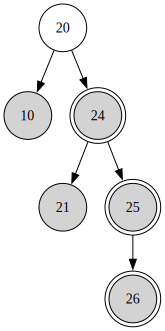

In [9]:
b = BST(20)
b.insert(24)
b.insert(21)
b.insert(10)
b.insert(25)
b.insert(26)
visualize_tree(b)

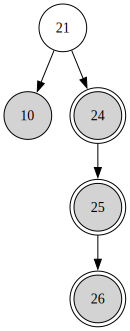

In [10]:
b = b.delete(20)
visualize_tree(b)

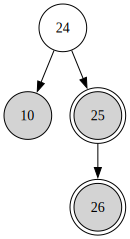

In [11]:
b = b.delete(21)
visualize_tree(b)

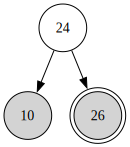

In [12]:
b = b.delete(25)
visualize_tree(b)

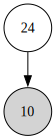

In [13]:
b = b.delete(26)
visualize_tree(b)

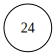

In [14]:
b = b.delete(10)
visualize_tree(b)

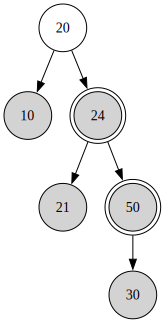

In [15]:
b = BST(20)
b.insert(24)
b.insert(21)
b.insert(10)
b.insert(50)
b.insert(30)
visualize_tree(b)

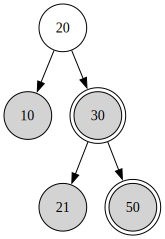

In [16]:
b = b.delete(24)
visualize_tree(b)

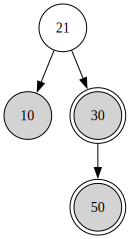

In [17]:
b = b.delete(20)
visualize_tree(b)


# Other Tree structures to Explore
### RB trees
### AVL trees

#### There are formed because of changing the head from one node to another node to keep the "balance" in the whole tree and take advantage of BST.  